In [16]:
import numpy as np
from gpaw import GPAW
from pathlib import Path
from wannierberri.utility import cached_einsum
from wannierberri.w90files.soc import SOC
from wannierberri.w90files.chk import CheckPoint as CHK
from wannierberri.system.system_R import System_R
from wannierberri.system.system_soc import SystemSOC

# Data directory
DATA_DIR = Path("tests") / "data" / "Fe_gpaw"

In [17]:
# Note: set_torque_operators_R is imported from SystemSOC
# rotated_pauli_commutators is imported from SOC (as a classmethod)
# Both are now part of the installed SOT_integration branch

In [3]:
def test_sot_hermiticity(system_Fe_gpaw_soc_z):
    sys = system_Fe_gpaw_soc_z
    sys.set_torque_operators_R(theta=0, phi=0)
    SOT = sys.get_R_mat('SOT')
    
    # Assuming R=0 is sorted to index 0, or find it via sys.rvec.iRvec
    r0_idx = np.where(np.all(sys.rvec.iRvec == [0, 0, 0], axis=1))[0][0]
    
    for alpha in range(3):
        T_0 = SOT[r0_idx, :, :, alpha]
        np.testing.assert_allclose(
            T_0, 
            T_0.conj().T, 
            atol=1e-10, 
            err_msg=f"SOT component {alpha} is not Hermitian at R=0"
        )

In [4]:
import numpy as np
import pytest

def test_sot_commutator_identity(system_Fe_gpaw_soc_z):
    sys = system_Fe_gpaw_soc_z
    sys.set_soc_axis(theta=0, phi=0, alpha_soc=1.0)
    sys.set_torque_operators_R(theta=0, phi=0)
    
    SOT = sys.get_R_mat('SOT') # Shape: (nRvec, Nw, Nw, 3)
    H_soc = sys.get_R_mat('Ham_SOC') # Shape: (nRvec, Nw, Nw)
    
    Nw = sys.num_wann
    nRvec = sys.rvec.nRvec
    
    # Construct full Nw x Nw Pauli matrices for the interleaved Wannier basis
    sig_x = np.zeros((Nw, Nw), dtype=complex)
    sig_y = np.zeros((Nw, Nw), dtype=complex)
    sig_z = np.zeros((Nw, Nw), dtype=complex)
    
    # Fill interleaved blocks
    sig_x[0::2, 1::2] = 1; sig_x[1::2, 0::2] = 1
    sig_y[0::2, 1::2] = -1j; sig_y[1::2, 0::2] = 1j
    sig_z[0::2, 0::2] = 1; sig_z[1::2, 1::2] = -1
    
    S_matrices = [sig_x, sig_y, sig_z]
    
    # Check the commutator [S_alpha, H_soc] for each R
    for alpha, S_alpha in enumerate(S_matrices):
        for r in range(nRvec):
            # Commutator: S * H_soc - H_soc * S
            comm = S_alpha @ H_soc[r] - H_soc[r] @ S_alpha
            
            # Note: Adjust the prefactor (-i/2) based on your exact definitions 
            # in get_analytical_commutators.
            T_expected = -0.5j * comm 
            
            np.testing.assert_allclose(
                SOT[r, :, :, alpha], 
                T_expected, 
                atol=1e-10, 
                err_msg=f"Commutator failed for direction {alpha} at R-vector index {r}"
            )

In [5]:
def test_sot_inversion_symmetry(system_Fe_gpaw_soc_z):
    sys = system_Fe_gpaw_soc_z
    sys.set_torque_operators_R(theta=0, phi=0)
    SOT = sys.get_R_mat('SOT')
    iRvec = sys.rvec.iRvec
    
    for r_idx, R in enumerate(iRvec):
        # Find the index of the inverse lattice vector -R
        minus_r_idx = np.where(np.all(iRvec == -R, axis=1))[0][0]
        
        for alpha in range(3):
            T_R = SOT[r_idx, :, :, alpha]
            T_minus_R = SOT[minus_r_idx, :, :, alpha]
            
            np.testing.assert_allclose(
                T_R, 
                T_minus_R.conj().T, 
                atol=1e-10, 
                err_msg=f"Inversion symmetry failed for component {alpha} at R={R}"
            )

In [6]:
def test_sot_equilibrium_trace(system_Fe_gpaw_soc_z):
    sys = system_Fe_gpaw_soc_z
    sys.set_torque_operators_R(theta=0, phi=0)
    SOT = sys.get_R_mat('SOT')
    
    # Locate the R=0 home unit cell
    r0_idx = np.where(np.all(sys.rvec.iRvec == [0, 0, 0], axis=1))[0][0]
    
    for alpha in range(3):
        T_0 = SOT[r0_idx, :, :, alpha]
        net_torque = np.trace(T_0)
        
        assert abs(net_torque) < 1e-10, \
            f"Net torque component {alpha} must be zero in equilibrium, got {net_torque}"

In [7]:
import numpy as np
from ase import Atoms
from gpaw import GPAW, PW, FermiDirac, MixerSum

In [8]:
calc_scf = GPAW("Fe-scf.gpw")
calc_nscf = GPAW("Fe-nscf-irred-444.gpw")
calc_bands = GPAW("Fe-bands-path.gpw")

In [10]:
a = 2.87 # Angstrom - lattice constant for bcc Fe
m = 2.2 # Bohr magneton - spin magnetic moment per atom

seed = "Fe"
lattice = a * np.array([[1, 1, 1], [-1, 1, 1], [-1, -1, 1]]) / 2

fe = Atoms('Fe',
           scaled_positions=[(0, 0, 0)],
           magmoms=[m],
           cell=lattice,
           pbc=True)

calc_scf = GPAW(mode=PW(600),
            xc='PBE',
            occupations=FermiDirac(width=0.01),
            kpts={'size': (8,8,8),},
            txt=f'Fe_scf.txt')
fe.calc = calc_scf
e = fe.get_potential_energy()
calc_scf.write(f'{seed}-scf.gpw')


In [11]:
from irrep.spacegroup import SpaceGroup
sg = SpaceGroup.from_gpaw(calc_scf)
kpoints_irred = sg.get_irreducible_kpoints_grid([4, 4, 4])
calc_nscf = calc_scf.fixed_density(
    kpts=kpoints_irred,
    nbands=30,
    convergence={'bands': 24},
    txt=f'{seed}-nscf.txt')
calc_nscf.write(f'{seed}-nscf-irred-444.gpw', mode='all')

typat used for spacegroup detection (accounting magmoms): [26]


In [12]:
from irrep.spacegroup import SpaceGroup
from wannierberri.symmetry.projections import Projection, ProjectionsSet
from gpaw import GPAW
# gpaw_calc = calc_nscf #GPAW( "./Fe-nscf-irred-444.gpw")
sg = SpaceGroup.from_gpaw(calc_nscf)
projection_sp3d2 = Projection(position_num=[0, 0, 0], orbital='sp3d2', spacegroup=sg)
projection_t2g = Projection(position_num=[0, 0, 0], orbital='t2g', spacegroup=sg)
proj_set = ProjectionsSet([projection_sp3d2, projection_t2g])

typat used for spacegroup detection (accounting magmoms): [26]


In [13]:
from wannierberri.w90files.w90data_soc import WannierDataSOC

wandata = WannierDataSOC.from_gpaw(
    calculator=calc_nscf,
    projections=proj_set,
    mp_grid=(4,4,4),
    spacegroup=sg,
)

Using 'projections' for both spin up channel.
No projections_down provided; using projections_up for both spin channels.
finding num points from 2 projections
finding num points from 2 projections
got irreducible=None, mp_grid=(4, 4, 4), seedname=wannier_soc-spin-0, files=['mmn', 'eig', 'amn', 'symmetrizer'],  projections=ProjectionsSet with 9 Wannier functions and 0 free variables
Projection 0, 0, 0:['sp3d2'] with 6 Wannier functions (6 per spin x1 spins) 
 on 1 points (6 per site)
Projection 0, 0, 0:['t2g'] with 3 Wannier functions (3 per spin x1 spins) 
 on 1 points (3 per site), unk_grid=None, normalize=True
mpgrid = [4 4 4], 8
detected grid=(np.int64(4), np.int64(4), np.int64(4)), selected_kpoints=[0 1 2 3 4 5 6 7]
self.irreducible=True
mpgrid = [4 4 4], 8


/home/eusta/tp4_ssp/wannier-berri/wannierberri/w90files/wandata.py:128: UserWarning: detected grid (np.int64(4), np.int64(4), np.int64(4)) od 64 kpoints, but only 8 kpoints are available.assuming that only irreducible kpoints are needed.
  warnings.warn(f"detected grid {grid} od {np.prod(grid)} kpoints, "


Shells found with weights [0.41728623] and tolerance 1.9302775581455037e-16
Creating amn. Using projections_set 
ProjectionsSet with 9 Wannier functions and 0 free variables
Projection 0, 0, 0:['sp3d2'] with 6 Wannier functions (6 per spin x1 spins) 
 on 1 points (6 per site)
Projection 0, 0, 0:['t2g'] with 3 Wannier functions (3 per spin x1 spins) 
 on 1 points (3 per site)
NK= 64, selected_kpoints = [0 1 2 3 4 5 6 7], kptirr = [0 1 2 3 4 5 6 7]
got irreducible=None, mp_grid=(4, 4, 4), seedname=wannier_soc-spin-1, files=['mmn', 'eig', 'amn', 'symmetrizer'],  projections=ProjectionsSet with 9 Wannier functions and 0 free variables
Projection 0, 0, 0:['sp3d2'] with 6 Wannier functions (6 per spin x1 spins) 
 on 1 points (6 per site)
Projection 0, 0, 0:['t2g'] with 3 Wannier functions (3 per spin x1 spins) 
 on 1 points (3 per site), unk_grid=None, normalize=True
mpgrid = [4 4 4], 8
detected grid=(np.int64(4), np.int64(4), np.int64(4)), selected_kpoints=[0 1 2 3 4 5 6 7]
self.irreducible

In [14]:
wandata.wannierise(
    froz_min=-100,
    froz_max=20,
    outer_min=-100,
    outer_max=np.inf,
    num_iter=100,
    print_progress_every=10,
    sitesym=True,
    localise=True,
)

/home/eusta/tp4_ssp/wannier-berri/wannierberri/parallel.py:121: UserWarning: ray package found, but ray is not initialized, running in serial mode
  warnings.warn("ray package found, but ray is not initialized, running in serial mode")


####################################################################################################
starting WFs
----------------------------------------------------------------------------------------------------
wannier centers and spreads
----------------------------------------------------------------------------------------------------
 -0.667073280629   -0.000000000000   -0.000000000000   |     2.273913461555
  0.667073280629    0.000000000000    0.000000000000   |     2.273913461555
  0.000000000000   -0.667073280629   -0.000000000000   |     2.273913461555
 -0.000000000000    0.667073280629    0.000000000000   |     2.273913461555
 -0.000000000000   -0.000000000000   -0.667073280629   |     2.273913461555
  0.000000000000    0.000000000000    0.667073280629   |     2.273913461555
  0.000000000000    0.000000000000    0.000000000000   |     0.603064978923
  0.000000000000    0.000000000000    0.000000000000   |     0.603064978923
  0.000000000000    0.000000000000    0.00000000

In [15]:
from wannierberri.system.system_soc import SystemSOC
theta = 0
phi = 0

system_soc = SystemSOC.from_wannierdata(wandata=wandata, berry=True, silent=False)
system_soc.set_soc_axis(theta=theta, phi=phi, alpha_soc=1.0)
system_soc.save_npz("system_soc")

irreducible : True, symmetrize set to True
setting Rvec
setting AA..
setting AA - OK
Real-space lattice:
 [[ 1.435  1.435  1.435]
 [-1.435  1.435  1.435]
 [-1.435 -1.435  1.435]]
Number of wannier functions: 9
Number of R points: 89
Recommended size of FFT grid [4 4 4]
num_blocks_left = 2, num_blocks_right = 2
number o R-vectors before symmetrization: 89
number o R-vectors after symmetrization: 89
irreducible : True, symmetrize set to True
setting Rvec
setting AA..
setting AA - OK
Real-space lattice:
 [[ 1.435  1.435  1.435]
 [-1.435  1.435  1.435]
 [-1.435 -1.435  1.435]]
Number of wannier functions: 9
Number of R points: 89
Recommended size of FFT grid [4 4 4]
num_blocks_left = 2, num_blocks_right = 2
number o R-vectors before symmetrization: 89
number o R-vectors after symmetrization: 89


/home/eusta/tp4_ssp/wannier-berri/wannierberri/utility.py:57: UserWarning: usually need to provide either with real or reciprocal lattice.If you only want to generate a random symmetric tensor - that it fine
  warnings.warn("usually need to provide either with real or reciprocal lattice."


nspin in SOC: 2
setting Rvec
using magmoms 
 [[0.         0.         2.21212609]]
num_blocks_left = 2, num_blocks_right = 2
num_blocks_left = 2, num_blocks_right = 2
num_blocks_left = 2, num_blocks_right = 2
using magmoms 
 [[0.         0.         2.21212609]]
using magmoms 
 [[0.         0.         2.21212609]]
Saving SystemSOC to system_soc
saving system of class SystemSOC to system_soc
 properties: ['num_wann', 'real_lattice', 'iRvec', 'periodic', 'is_phonon', 'wannier_centers_cart', 'pointgroup', 'cell']
saving num_wann to system_soc/num_wann.npz
saving real_lattice to system_soc/real_lattice.npz
saving iRvec to system_soc/iRvec.npz
saving periodic to system_soc/periodic.npz
saving is_phonon to system_soc/is_phonon.npz
saving wannier_centers_cart to system_soc/wannier_centers_cart.npz
saving pointgroup to system_soc/pointgroup.npz
saving cell to system_soc/cell.npz
saving system of class System_R to system_soc/system_up
 properties: ['num_wann', 'real_lattice', 'iRvec', 'periodic',

In [18]:
from wannierberri.grid import Path
from wannierberri.evaluate_k import evaluate_k_path
# from wannierberri.system.system_soc import SystemSOC
# system_soc = SystemSOC.from_npz("system_soc")

points = {"G": [0.0, 0.0, 0.0],
          "H": [0.5, -0.5, -0.5],
          "P": [0.75, 0.25, -0.25],
          "N": [0.5, 0.0, -0.5],
         }

path_str = "GHPNGP"
path = Path.from_nodes(real_lattice=system_soc.real_lattice,
            nodes=[points[p] for p in path_str],
            labels=[p for p in path_str],
            length=1000)   # length [ Ang] ~= 2*pi/dk

bands_wannier_soc= evaluate_k_path(system_soc, path=path, quantities=["spin"])
bands_wannier_up = evaluate_k_path(system_soc.system_up, path=path)
bands_wannier_dw = evaluate_k_path(system_soc.system_down, path=path)

Starting run()
Using the follwing calculators : 
############################################################

 'tabulate'  :  <wannierberri.calculators.tabulate.TabulatorAll object at 0x7cc169caffe0>  : 
    TabulatorAll - a pack of all k-resolved calculators (Tabulators)
    
 Includes the following tabulators : 
--------------------------------------------------
 "spin" : <wannierberri.calculators.tabulate.Spin object at 0x7cc1729325d0> :  Spin expectation :math:` \langle u | \mathbf{\sigma} | u \rangle`

 "Energy" : <wannierberri.calculators.tabulate.Energy object at 0x7cc165f10050> : calculator not described

--------------------------------------------------

############################################################
Calculation along a path - checking calculators for compatibility
tabulate <wannierberri.calculators.tabulate.TabulatorAll object at 0x7cc169caffe0>
All calculators are compatible
Symmetrization switched off for Path
Grid is regular
The set of k points is a Path() 

/home/eusta/tp4_ssp/wannier-berri/wannierberri/grid/path.py:272: UserWarning: symmetry is not used for a tabulation along path
  warnings.warn("symmetry is not used for a tabulation along path")


                  70              5.1                  95.0                 100.1
                 420             10.3                  23.4                  33.7
                 798             15.5                  11.2                  26.7
                1190             20.6                   3.2                  23.8
time for processing   1373 K-points on   1 processes:    23.1603 ; per K-point          0.0169 ; proc-sec per K-point          0.0169
time1 =  7.152557373046875e-07
Totally processed 1373 K-points 
run() finished
Starting run()
Using the follwing calculators : 
############################################################

 'tabulate'  :  <wannierberri.calculators.tabulate.TabulatorAll object at 0x7cc165b783b0>  : 
    TabulatorAll - a pack of all k-resolved calculators (Tabulators)
    
 Includes the following tabulators : 
--------------------------------------------------
 "Energy" : <wannierberri.calculators.tabulate.Energy object at 0x7cc1694cdb50> : calculato

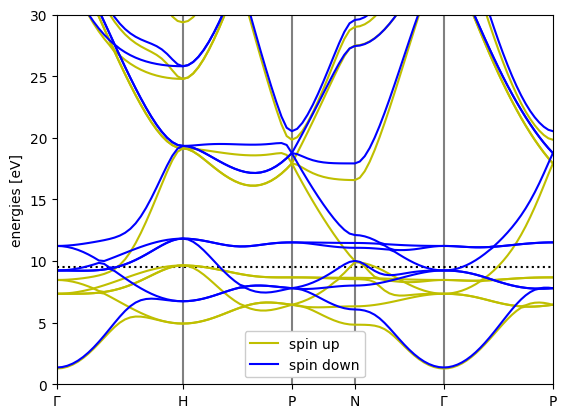

<Axes: ylabel='energies [eV]'>

In [20]:
path_str = "GHPNGP"
calc_bands = calc_scf.fixed_density(
    nbands=30,
    symmetry='off',
    random=True,
    kpts={'path': path_str, 'npoints': 100},
    txt=f'{seed}-bands-path.txt',
    convergence={'bands': 24})
calc_bands.write(f'{seed}-bands-path.gpw', mode='all')


bs_dft = calc_bands.band_structure()
bs_dft.plot(show=True, emin=0,emax=30.0)

/home/eusta/tp4_ssp/.venv/lib/python3.12/site-packages/ase/spectrum/band_structure.py:352: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  leg = plt.legend(loc=loc)


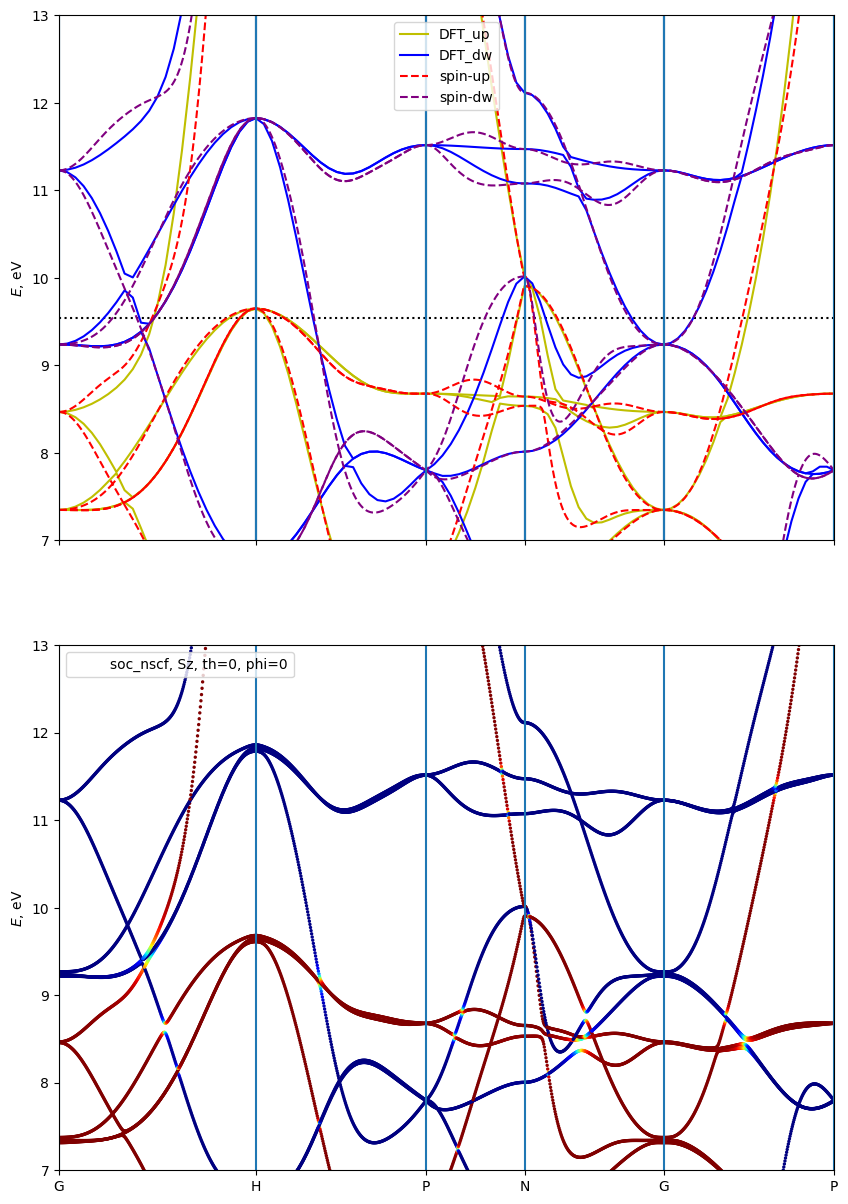

In [21]:
EF = 9.53754
EF=0
from matplotlib import pyplot as plt
fig, axes = plt.subplots(2, 1, sharey=True, sharex=True, figsize=(10, 15))

theta = 0
phi = 0

bs_dft.plot(show=False, emin=0,emax=30.0, ax=axes[0] ,  label=["DFT_up", "DFT_dw"])

bands_wannier_soc.plot_path_fat(path=path,
                       Eshift=EF,
                       quantity="spin",
                       component="z",
                       mode="color",
                       label=f"soc_nscf, Sz, th={theta}, phi={phi}",
                       axes=axes[1],
                       fatmax=2,
                        linecolor="orange",
                        close_fig=False,
                        show_fig=False,
                        kwargs_line=dict(linestyle='-', lw=0.0),
)
#

bands_wannier_up.plot_path_fat(
                            path=path,
                            Eshift=EF,
                            axes=axes[0],
                            label="spin-up",
                            linecolor="red",
                            kwargs_line=dict(linestyle='--'),
                            close_fig=False,
                            show_fig=False)

bands_wannier_dw.plot_path_fat(
                        path=path,
                       label="spin-dw",
                       axes=axes[0],
                       Eshift=EF,
                       linecolor="purple",
                       kwargs_line=dict(linestyle='--'),
                       close_fig=False,
                       show_fig=False,)
plt.ylim(7, 13)
plt.show()

In [3]:
# 1. Check the top-level keys
print("Top-level keys:", bands_sot.results.keys())

# 2. Inspect the 'SOT' entry specifically
# Depending on the version, it might be directly in results or under 'tabulate'
sot_entry = bands_sot.results.get('tabulate', {}).get('SOT', bands_sot.results.get('SOT'))

if sot_entry:
    print("\nSOT Object Type:", type(sot_entry))
    # 'data' usually contains the (nk, nbands, n_dim) array
    print("SOT Data Shape:", sot_entry.data.shape)

Top-level keys: dict_keys(['SOT', 'Energy'])

SOT Object Type: <class 'wannierberri.result.kbandresult.KBandResult'>
SOT Data Shape: (1373, 18, 3)


In [1]:
print("Coordinates are here:", bands_sot.results["Energy"].k_path)

NameError: name 'bands_sot' is not defined

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import wannierberri as wberri
from wannierberri.system.system_soc import SystemSOC
from wannierberri.grid import Path
from wannierberri.evaluate_k import evaluate_k_path
from wannierberri.formula.formula import Matrix_ln
from wannierberri.calculators.tabulate import Tabulator

# 1. Load system, compute operators, define custom formula
system_soc = SystemSOC.from_npz("system_soc")
system_soc.set_torque_operators_R(theta=0, phi=0)

from wannierberri.formula.formula import Matrix_ln

class SOTformula(Matrix_ln):
    def __init__(self, data_K, **kwargs):
        # 1. Fetch the pre-built Matrix_ln object from covariant()
        T_obj = data_K.covariant('SOT')
        
        # 2. Extract the raw numpy array from the object
        raw_matrix = T_obj.matrix
        
        # 3. Pass the raw array to properly initialize this subclass
        super().__init__(matrix=raw_matrix, **kwargs)

# 2. Path setup & Evaluation
pts = {"G": [0,0,0], "H": [0.5,-0.5,-0.5], "P": [0.75,0.25,-0.25], "N": [0.5,0.0,-0.5]}
path = Path.from_nodes(
    system=system_soc, 
    nodes=[pts[p] for p in "GHPNGP"], 
    labels=list("GHPNGP"), 
    length=1000
)
bands_sot = evaluate_k_path(system_soc, path=path, tabulators={"SOT": Tabulator(SOTformula)})

loading real_lattice - Ok!
loading wannier_centers_cart - Ok!
loading iRvec - Ok!
loading pointgroup - Ok!
loading is_phonon - Ok!
loading periodic - Ok!
loading positions - Ok!
loading atom_labels - Ok!
loading num_wann - Ok!
loading R_matrix Ham - Ok!
loading R_matrix AA - Ok!
loading real_lattice - Ok!
loading wannier_centers_cart - Ok!
loading iRvec - Ok!
loading pointgroup - Ok!
loading is_phonon - Ok!
loading periodic - Ok!
loading positions - Ok!
loading atom_labels - Ok!
loading num_wann - Ok!
loading R_matrix Ham - Ok!
loading R_matrix AA - Ok!


/home/eusta/tp4_ssp/wannier-berri/wannierberri/utility.py:57: UserWarning: usually need to provide either with real or reciprocal lattice.If you only want to generate a random symmetric tensor - that it fine
  warnings.warn("usually need to provide either with real or reciprocal lattice."


Starting run()
Using the follwing calculators : 
############################################################

 'tabulate'  :  <wannierberri.calculators.tabulate.TabulatorAll object at 0x76f7b88dc770>  : 
    TabulatorAll - a pack of all k-resolved calculators (Tabulators)
    
 Includes the following tabulators : 
--------------------------------------------------
 "SOT" : <wannierberri.calculators.tabulate.Tabulator object at 0x76f7b730e360> : calculator not described

 "Energy" : <wannierberri.calculators.tabulate.Energy object at 0x76f7b6c993d0> : calculator not described

--------------------------------------------------

############################################################
Calculation along a path - checking calculators for compatibility
tabulate <wannierberri.calculators.tabulate.TabulatorAll object at 0x76f7b88dc770>
All calculators are compatible
Symmetrization switched off for Path
Grid is regular
The set of k points is a Path() with 1373 points and labels {0: 'G', 3

/home/eusta/tp4_ssp/wannier-berri/wannierberri/parallel.py:121: UserWarning: ray package found, but ray is not initialized, running in serial mode
  warnings.warn("ray package found, but ray is not initialized, running in serial mode")
/home/eusta/tp4_ssp/wannier-berri/wannierberri/grid/path.py:272: UserWarning: symmetry is not used for a tabulation along path
  warnings.warn("symmetry is not used for a tabulation along path")


                 168              5.2                  37.4                  42.7
                 364             10.5                  29.0                  39.5
                 672             15.7                  16.4                  32.0
                1162             20.7                   3.8                  24.5
time for processing   1373 K-points on   1 processes:    22.7112 ; per K-point          0.0165 ; proc-sec per K-point          0.0165
time1 =  7.152557373046875e-07
Totally processed 1373 K-points 
run() finished


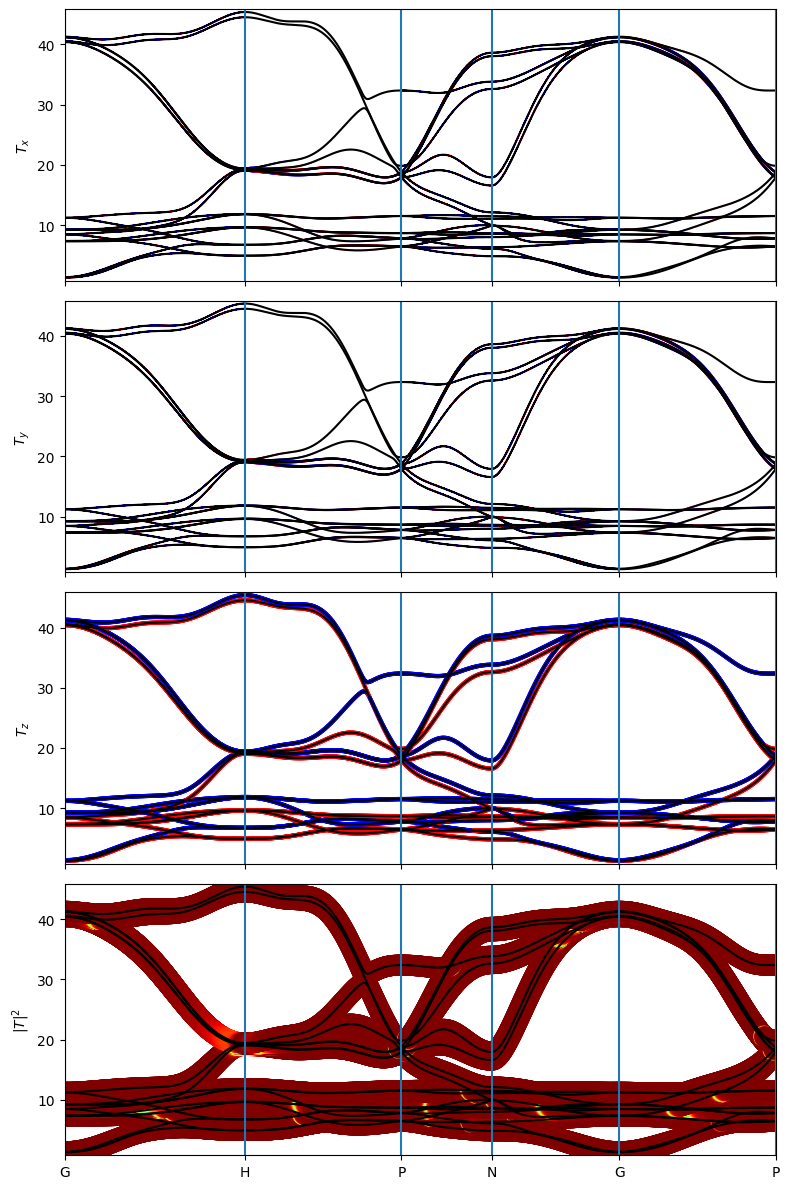

In [14]:
# 1. Initialize figure
fig, axs = plt.subplots(4, 1, sharex=True, figsize=(8, 12))

# 2. Plot Cartesian components (0, 1, 2)
for i, comp in enumerate(["x", "y", "z"]):
    bands_sot.plot_path_fat(path=path, quantity="SOT", component=comp, 
                            axes=axs[i], fig=fig, 
                            show_fig=False, close_fig=False)
    axs[i].set_ylabel(f"$T_{comp}$")

# 3. Plot Total Amplitude squared using the "color" mode
# component="sq" triggers np.linalg.norm(data)**2 internally
bands_sot.plot_path_fat(path=path, quantity="SOT", component="sq", 
                        mode="color", axes=axs[3], fig=fig,
                        show_fig=False, close_fig=False)

axs[3].set_ylabel("$|T|^2$")

plt.tight_layout()
plt.show()

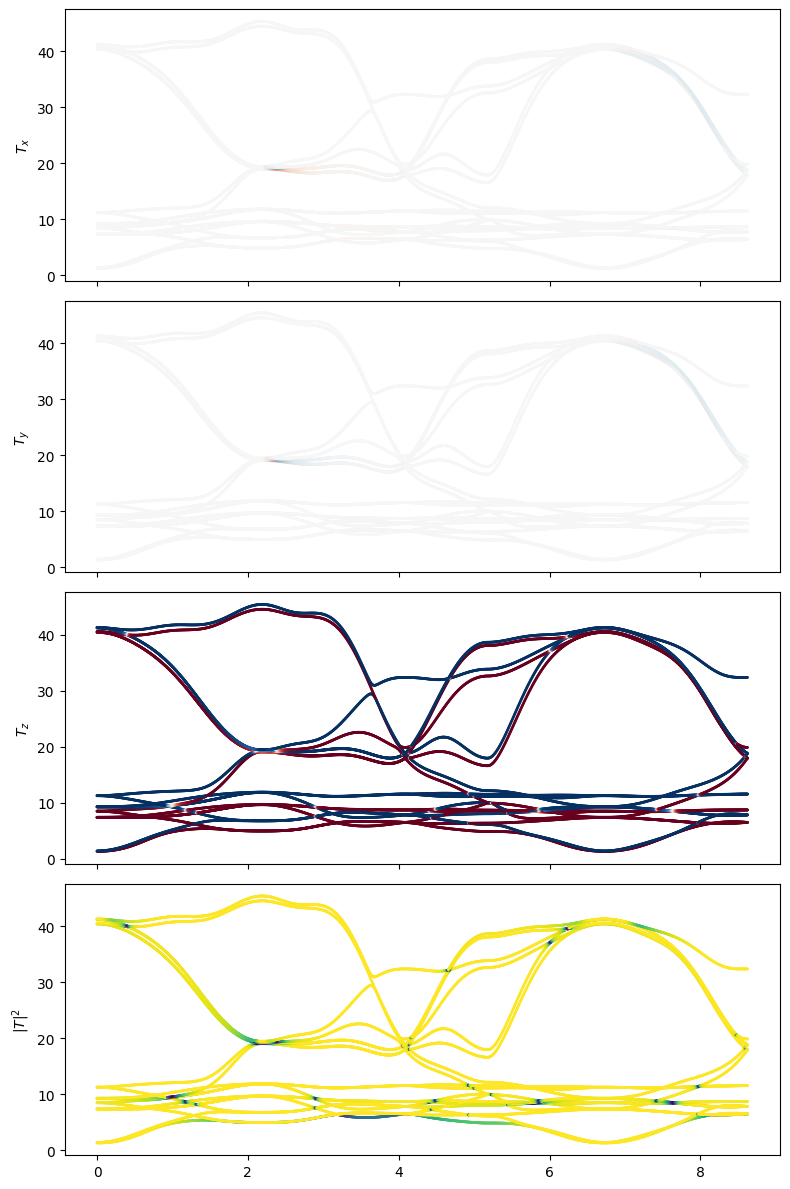

In [16]:
# 1. Initialize figure
fig, axs = plt.subplots(4, 1, sharex=True, figsize=(8, 12))
kline = path.getKline()

# 2. Manual Plotting to verify uniqueness
sot_res = bands_sot.results["SOT"].data  # shape (nk, nbands, 3)
eng_res = bands_sot.results["Energy"].data

for i, comp in enumerate(["x", "y", "z"]):
    # Manually select the i-th component from the last dimension
    data_comp = sot_res[..., i] 
    
    for b in range(eng_res.shape[1]):
        # We use a simple scatter to see the raw values
        axs[i].scatter(kline, eng_res[:, b], c=data_comp[:, b], 
                       cmap='RdBu_r', s=1, vmin=-np.max(np.abs(sot_res)), 
                       vmax=np.max(np.abs(sot_res)))
    axs[i].set_ylabel(f"$T_{comp}$")

# 3. Amplitude (The robust way)
amp = np.sum(np.abs(sot_res)**2, axis=-1)
for b in range(eng_res.shape[1]):
    sc = axs[3].scatter(kline, eng_res[:, b], c=amp[:, b], cmap='viridis', s=1)

# Formatting
axs[3].set_ylabel("$|T|^2$")
plt.tight_layout()
plt.show()